# Domain-Specific Fine Tuning of Large LanguageModels for Professional Medical QA Systems  

Xuyang Zheng  
Zilong Wang

# Introduction

This project focuses on optimizing a lightweight Large Language Model (LLM) using Parameter-Efficient Fine-Tuning (PEFT) through the LoRA framework to address the limitations of general-purpose models in the medical domain, specifically regarding professional depth and factual hallucinations. The primary impact on decision-making lies in enhancing the preliminary medical screening and triage process. By providing contextually accurate, logic-driven medical insights, the system assists both patients and healthcare providers in determining the urgency of clinical interventions, thereby optimizing the prioritization of emergency versus routine care.

In the landscape of artificial intelligence, LLMs have demonstrated remarkable capabilities. However, their application in high-stakes environments, such as the medical domain, remains limited by issues such as hallucinations and a lack of specialized clinical depth. This project aims to bridge this gap by performing domain-specific fine-tuning on a lightweight base model (Qwen-0.5B). Our objective is to develop a specialized QA system capable of providing professional, accurate, and contextually appropriate medical consultation.

The primary goal of this system is to enhance the preliminary medical screening and triage process. By leveraging a fine-tuned LLM, patients and healthcare providers can receive immediate, evidence-based insights into symptoms and potential conditions. This impacts decision-making by helping users determine the urgency of medical intervention—distinguishing between routine symptoms and those requiring immediate emergency care—thereby optimizing the allocation of clinical resources.

The implementation of a domain-specific medical LLM offers significant business advantages:

- Operational Efficiency: Provides a scalable, 24/7 first-line medical inquiry service, reducing the administrative and consultative burden on healthcare staff.

- Cost Optimization: Lowers the barrier to accessing professional health information, potentially reducing unnecessary ER visits through better-informed patient self-assessment.

- Specialization as a Competitive Edge: Unlike generic chatbots, a model fine-tuned on curated medical dialogues offers a higher degree of trust and reliability, essential for integration into Telehealth platforms and pharmaceutical advisory services.


# Dataset Preview

In [61]:
import torch
import os
import numpy as np
import json

import matplotlib.pyplot as plt
from datasets import load_dataset
from typing import Optional
from dataclasses import dataclass, field
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    HfArgumentParser,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    set_seed
)
from peft import LoraConfig, TaskType, get_peft_model
from IPython.display import Image, display


DATA_PATH = "C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl"
MODEL_PATH = "C:/Projects/ESE5971/models/qwen0.5b"

In [41]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

samples = np.random.choice(data, size=1, replace=False)

for sample in samples:
    print(sample)

{'conversations': [{'from': 'human', 'value': "If you are a doctor, please answer the medical questions based on the patient's description.\n\nI have a small, smooth red lump on my right upper arm. It is about 1cm squared in size and slightly raised. It doesnt itch and doesnt irritate. Ive had it for many years and it hasnt changed at all. Links to what it looks like are:  WWW.WWWW.WW        and         WWW.WWWW.WW"}, {'from': 'gpt', 'value': "Thanks for your question on Chat Doctor. I can understand your situation and problem. Following are the possible causes for your painless, stable upper arm lump. 1. Hematoma 2. Lipoma 3. Desmond (less likely) 4. Fibroid (less likely) Since your swelling is not causing you any trouble like not painful, not enlarging in size, non-itchy, not restricting the movements etc., no treatment is required for it. So don't worry about this swelling."}]}


In the data description phase, we utilized the industry-standard ShareGPT format for multi-turn dialogue construction. To ensure the model accurately recognizes boundaries between different conversational roles, we implemented a ChatML structural encoding scheme. By incorporating structural tokens such as <|im_start|> and <|im_end|>, we transformed raw text into a formatted structure with distinct boundaries for system instructions, user inputs, and assistant responses.

# Data Preprocessing

The dataset used comes from the project ChatDoctor, which contains approximately 100,000 instruction–response pairs designed for medical tasks. Each sample in the dataset follows conversation format to simulate patients and doctors, which is related to user query and corresponding medical response.

Unlike traditional machine learning tasks that operate on numerical features, large language model (LLM) fine-tuning uses natural language text as inputs. This leads to the preprocessing and analysis procedures differ from those typically used for structured numerical datasets. Since LLMs process text in the form of tokens, we compute each sample’s token length in order to better understanding their distribution and ensures that most samples fall within the supported sequence range of the model, which helps balance computational efficiency and information retention during training.

In [42]:
def is_valid_conversation(convs):
    """
    Decoupled Check 1: Null/Empty Validation.
    """
    if not convs or len(convs) == 0:
        return False
    
    for msg in convs:
        if not str(msg.get("value", "")).strip():
            return False
    return True

def is_duplicate(convs, seen_hashes):
    """
    Decoupled Check 2: Duplicate Detection.
    """
    conv_sig = json.dumps(convs, sort_keys=True)
    if conv_sig in seen_hashes:
        return True
    
    seen_hashes.add(conv_sig)
    return False

def calculate_token_length(convs, tokenizer):
    """
    Decoupled Check 3: Token Length Calculation (ChatML format).
    """
    input_ids = []
    
    # Simulate System Prompt
    sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    input_ids.extend(tokenizer.encode(sys_prompt, add_special_tokens=False))
    
    # Simulate Multi-turn Conversation
    for msg in convs:
        role = msg.get("from", "").lower()
        value = msg.get("value", "")
        
        if role in ["human", "user"]:
            text = f"<|im_start|>user\n{value}<|im_end|>\n"
        elif role in ["gpt", "assistant", "bot"]:
            text = f"<|im_start|>assistant\n{value}<|im_end|>\n"
        else:
            continue
            
        input_ids.extend(tokenizer.encode(text, add_special_tokens=False))
        
    return len(input_ids)

def plot_length_distribution(lengths):
    """
    Decoupled Task 4: Visualization.
    Generates a histogram of token lengths.
    """
    if not lengths:
        print("No data available to plot.")
        return

    # Using standard matplotlib plotting
    plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Labeling the axes and title
    plt.xlabel('Token Length')
    plt.ylabel('Number of Samples (Frequency)')
    plt.title('Distribution of Token Lengths')
    
    # Adding grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    

def main():
    print(f"Loading Tokenizer: {MODEL_PATH}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=False)
    
    print(f"Loading Dataset: {DATA_PATH}")
    dataset = load_dataset("json", data_files=DATA_PATH)["train"]
    
    lengths = []
    seen_hashes = set()
    
    # Statistics counters
    total_initial = len(dataset)
    empty_count = 0
    duplicate_count = 0

    print("Starting decoupled preprocessing and analysis...")
    
    for example in dataset:
        convs = example.get("conversations", [])
        
        if not is_valid_conversation(convs):
            empty_count += 1
            continue
            
        if is_duplicate(convs, seen_hashes):
            duplicate_count += 1
            continue
            
        token_len = calculate_token_length(convs, tokenizer)
        lengths.append(token_len)

    # Plot Data Distribution
    plot_length_distribution(lengths)

    # ================= Final Report =================
    lengths_np = np.array(lengths)
    print("\n=============== Data Analysis Report ===============")
    print(f"Initial Total:      {total_initial} samples")
    print(f"Empty/Invalid:      {empty_count} samples")
    print(f"Duplicates:         {duplicate_count} samples")
    print(f"Final Valid Total:  {len(lengths)} samples")
    print("-" * 45)
    if len(lengths_np) > 0:
        print(f"Min Length:         {np.min(lengths_np)} tokens")
        print(f"Max Length:         {np.max(lengths_np)} tokens")
        print(f"Mean Length:        {np.mean(lengths_np):.2f} tokens")
        print(f"95th Percentile:    {np.percentile(lengths_np, 95):.0f} tokens")
    print("======================================================\n")

Loading Tokenizer: C:/Projects/ESE5971/models/qwen0.5b
Loading Dataset: C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl
Starting decoupled preprocessing and analysis...


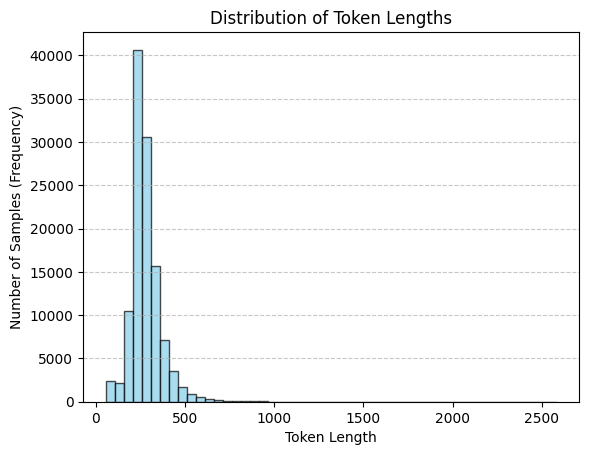


=============== Data Analysis Report ===============
Initial Total:      116617 samples
Empty/Invalid:      0 samples
Duplicates:         0 samples
Final Valid Total:  116617 samples
---------------------------------------------
Min Length:         55 tokens
Max Length:         2583 tokens
Mean Length:        276.35 tokens
95th Percentile:    430 tokens



In [43]:
main()

The figure above shows the histogram of token lengths across samples in the dataset. Most samples are concentrated in the range of 200 to 400 tokens, indicating that the majority of conversations are of moderate length. The distribution is slightly right-skewed, with a small number of samples extending to much longer sequences, forming a long-tail distribution. In rare cases, sequence lengths exceed 2500 tokens would be treated as outliers and considered to be truncated.

# How Tokens Looks Like

In [44]:
sample = {
    "conversations": [
        {
            "from": "human",
            "value": "Hi, how are you?"
        },
        {
            "from": "gpt",
            "value": "Hi I'm good! How can I help you?"
        }
    ]
}

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    use_fast=False
)

def build_input(convs, tokenizer):
    input_ids = []

    # system prompt
    sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    input_ids.extend(tokenizer.encode(sys_prompt, add_special_tokens=False))

    for msg in convs:
        role = msg["from"]
        value = msg["value"]

        if role in ["human", "user"]:
            text = f"<|im_start|>user\n{value}<|im_end|>\n"
        else:
            text = f"<|im_start|>assistant\n{value}<|im_end|>\n"

        input_ids.extend(tokenizer.encode(text, add_special_tokens=False))

    return input_ids

input_ids = build_input(sample["conversations"], tokenizer)

tokens = tokenizer.convert_ids_to_tokens(input_ids)

for i in range(30):
    print(input_ids[i], tokens[i])
print("Token length:", len(input_ids))

151644 <|im_start|>
8948 system
198 Ċ
2610 You
525 Ġare
264 Ġa
10950 Ġhelpful
17847 Ġassistant
13 .
151645 <|im_end|>
198 Ċ
151644 <|im_start|>
872 user
198 Ċ
13048 Hi
11 ,
1246 Ġhow
525 Ġare
498 Ġyou
30 ?
151645 <|im_end|>
198 Ċ
151644 <|im_start|>
77091 assistant
198 Ċ
13048 Hi
358 ĠI
2776 'm
1661 Ġgood
0 !
Token length: 38


This example illustrates how text is tokenized into a sequence of token IDs before being fed into the model. Each word or subword is converted into numerical tokens (including special tokens like <|im_start|> and <|im_end|> to structure the conversation), resulting in a total sequence length of 38 tokens.

Further statistical analysis reveals that the 95% of token length is approximately 430, meaning that 95% of the samples are shorter than this value. This observation provides useful guidance for configuring the maximum sequence length during model fine-tuning. Setting the maximum sequence length to 512 tokens allows the model to cover the majority of the dataset while maintaining reasonable computational efficiency. Samples exceeding this limit can be truncated during preprocessing. In addition to length analysis, we also performed basic data quality checks on the dataset. The results show that no empty or invalid samples were detected and no duplicate entries were found. Therefore, all samples were retained for further preprocessing and training.

# Model Update

## Fine Tuning Parameters

In [45]:
@dataclass
class ScriptArguments:
    model_name_or_path: str = field(
        metadata={"help": "Local model directory"}
    )

    data_path: str = field(
        metadata={"help": "Local dataset directory"}
    )

    max_train_samples: Optional[int] = field(
        default = None,
        metadata = {"help": "Number of data you want to use for training"}
    )

    lora_rank: int = field(
        default=16, 
        metadata={"help": "Rank of the LoRA"}
    )

    lora_alpha: int = field(
        default=32, 
        metadata={"help": "LoRA alpha parameter"}
    )

    lora_dropout: float = field(
        default = 0.05,
        metadata = {"help": "LoRA dropout probability"}
    )

    max_seq_length: int = field(
        default=512, 
        metadata={"help": "Maximum model context length. Suggested: 8192, 4096, 2048, 1024, 512"}
    )

We fine-tune the base language model using Low-Rank Adaptation (LoRA), which enables parameter-efficient training by introducing low-rank matrices into the original model weights. The key training arguments are defined as follows:

model_name_or_path: The local directory of the pre-trained base model used for fine-tuning.

data_path: Indicates the local path to the training dataset. 

max_train_samples: Limits the number of training samples used during fine-tuning. This is mainly used for quick experiments or debugging to reduce computational cost.

lora_rank: Defines the rank of the low-rank decomposition matrices. A larger rank increases model capacity but also computational cost.

lora_alpha: A scaling factor applied to the LoRA updates, controls the magnitude of the injected low-rank adaptation. Typically, α is set proportional to the rank.

lora_dropout: Dropout applied to LoRA layers to improve generalization and prevent overfitting during fine-tuning.

max_seq_length: Maximum input sequence length. Based on dataset statistics, 512 tokens cover the majority of samples while maintaining computational efficiency.

# LoRA Mechanism

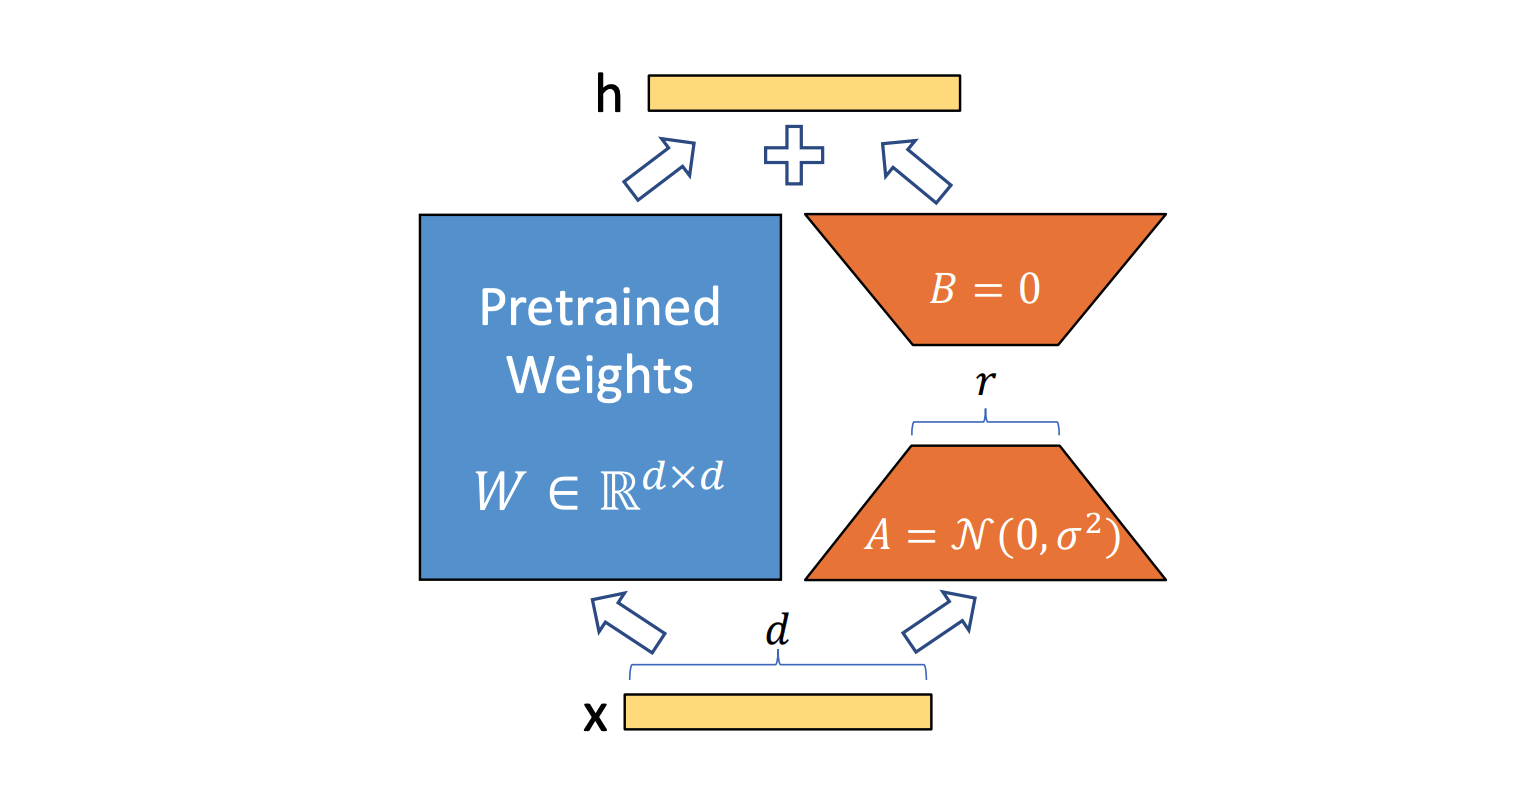

In [62]:
display(Image(filename="C:/Projects/ESE5971/reports/lora.png"))

Low-Rank Adaptation is a parameter-efficient fine-tuning method for large language models. Instead of updating the full weight matrix of the model, LoRA keeps the original weights frozen and introduces two small trainable matrices to represent the weight update. During training, the original model weights are not changed, only the inserted low-rank matrices are updated. These matrices learn how to adapt the model to the new task. At inference time, the learned updates can be merged back into the original weights or kept as separate adapters for flexible deployment.

## Training Script

In [56]:
DATA_PATH = "C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl"
MODEL_PATH = "C:/Projects/ESE5971/models/qwen0.5b"

def main():
    parser = HfArgumentParser((ScriptArguments, TrainingArguments))
    script_args, training_args = parser.parse_json_file("C:/Projects/ESE5971/config.json")

    script_args.model_name_or_path = MODEL_PATH
    script_args.data_path = DATA_PATH
    
    set_seed(training_args.seed)
    IGNORE_INDEX = -100 # Ignore non-answering part when calculating loss

    print(f"Initializing Training | Model: {script_args.model_name_or_path}")

    # ================= Loading Tokenizer (Qwen + ChatML) =================
    tokenizer = AutoTokenizer.from_pretrained(script_args.model_name_or_path, use_fast=False)
    
    # EOS token: <|im_end|>
    # Find id of pad token 
    if tokenizer.pad_token is None or tokenizer.pad_token_id is None:
        tokenizer.pad_token = "<|im_end|>"
        tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
        if tokenizer.pad_token_id is None: # backtrack to eos_token if id not obtained
            tokenizer.pad_token_id = tokenizer.eos_token_id
            
    tokenizer.padding_side = "right"

    # ================= Preprocessing ShareGPT Dataset =================
    full_dataset = load_dataset("json", data_files=script_args.data_path)["train"]

    # Triggering Shuffle Logic when max_train_samples is set
    if getattr(script_args, "max_train_samples", None) is not None:
        if len(full_dataset) > script_args.max_train_samples:
            print(f"Original sample amount ({len(full_dataset)}) excess limit ({script_args.max_train_samples})")
            print("Shuffling samples...")
            full_dataset = full_dataset.shuffle(seed=42).select(range(script_args.max_train_samples))
            print(f"Sampling finished! Now we have: {len(full_dataset)} samples.")

    # Train Test Split
    split_dataset = full_dataset.train_test_split(test_size = 0.1, seed = 42)
    raw_train = split_dataset["train"]
    raw_eval = split_dataset["test"]
    
    def preprocess_sharegpt(examples):
        input_ids_list, labels_list = [], []
        
        for conversations in examples["conversations"]:
            input_ids, labels = [], []
            
            # Plug in system prompt
            sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
            sys_ids = tokenizer.encode(sys_prompt, add_special_tokens=False)
            input_ids.extend(sys_ids)
            labels.extend([IGNORE_INDEX] * len(sys_ids)) # System Prompt not participate in Loss calculation

            # Iterate 'conversations' among the dataset
            for msg in conversations:
                role = msg.get("from", "")
                value = msg.get("value", "")

                if role in ["human", "user"]:
                    text = f"<|im_start|>user\n{value}<|im_end|>\n"
                    ids = tokenizer.encode(text, add_special_tokens=False)
                    input_ids.extend(ids)
                    labels.extend([IGNORE_INDEX] * len(ids))

                elif role in ["assistant", "gpt"]:
                    text = f"<|im_start|>assistant\n{value}<|im_end|>\n"
                    ids = tokenizer.encode(text, add_special_tokens=False)
                    input_ids.extend(ids)
                    labels.extend(ids)

            # Truncating Logic
            if len(input_ids) > script_args.max_seq_length:
                input_ids = input_ids[:script_args.max_seq_length]
                labels = labels[:script_args.max_seq_length]

            input_ids_list.append(input_ids)
            labels_list.append(labels)

        return {"input_ids": input_ids_list, "labels": labels_list}

    print("Analysing ShareGPT dataset...")
    tokenized_train = raw_train.map(
        preprocess_sharegpt, 
        batched=True, 
        remove_columns=raw_train.column_names,
        desc="Tokenizing ShareGPT"
    )

    tokenized_eval = raw_eval.map(
        preprocess_sharegpt,
        batched = True,
        remove_columns=raw_eval.column_names   
    )

    # ================= Load Model =================
    model = AutoModelForCausalLM.from_pretrained(
        script_args.model_name_or_path,
        device_map="auto",
        torch_dtype=torch.bfloat16 if training_args.bf16 else torch.float16
    )
    model.config.use_cache = False 

    # ================= Load LoRA =================
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    peft_config = LoraConfig(
        task_type = TaskType.CAUSAL_LM,
        r = script_args.lora_rank,
        lora_alpha = script_args.lora_alpha,
        lora_dropout = script_args.lora_dropout,
        target_modules = target_modules
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    # ================= Train =================
    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        label_pad_token_id=IGNORE_INDEX,
        padding=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset = tokenized_eval,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    print("Start Training...")
    trainer.train()
    trainer.save_model(training_args.output_dir)

    print(f"Training Completed")

    # ================= Plot Loss Curve =================
    log_history = trainer.state.log_history
    
    train_steps = []
    train_losses = []
    eval_steps = []
    eval_losses = []
    
    for log in log_history:
        if "loss" in log and "eval_loss" not in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])
        if "eval_loss" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])
    
    print("Train logs:", list(zip(train_steps, train_losses)))
    print("Eval logs:", list(zip(eval_steps, eval_losses)))
    
    plt.figure(figsize=(8, 5))
    if train_steps:
        plt.plot(train_steps, train_losses, marker="o", label="Train Loss")
    if eval_steps:
        plt.plot(eval_steps, eval_losses, marker="s", label="Eval Loss")
    
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training / Evaluation Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# Smoke Test and Preliminary Results

We conducted a small-scale smoke test using the Qwen 0.5B model and a subset of 200 training samples. This experiment is designed for testing purposes only, aiming to verify that the training pipeline, data preprocessing, and LoRA fine-tuning setup works correctly. During training, we logged both training loss and validation loss at regular intervals.
These metrics allow us to visually and quantitatively track the model's learning behavior, helping us identify issues such as instability, overfitting, or convergence trends.

Initializing Training | Model: C:/Projects/ESE5971/models/qwen0.5b
Original sample amount (116617) excess limit (200)
Shuffling samples...
Sampling finished! Now we have: 200 samples.
Analysing ShareGPT dataset...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 378.70it/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826
Start Training...


Step,Training Loss,Validation Loss
20,2.580230,2.815914
40,2.226181,2.757663
60,2.670486,2.744976
80,2.764973,2.739842
100,2.694882,2.734070
120,2.752584,2.729256
140,2.560896,2.724985
160,2.660888,2.725192
180,2.068596,2.723869


Training Completed
Train logs: [(1, 3.733154058456421), (10, 2.624690161810981), (20, 2.5802303314208985), (30, 2.356393051147461), (40, 2.226180648803711), (50, 2.2609956741333006), (60, 2.670486259460449), (70, 2.6477687835693358), (80, 2.7649730682373046), (90, 2.7096717834472654), (100, 2.6948820114135743), (110, 2.585714340209961), (120, 2.752583885192871), (130, 2.3511085510253906), (140, 2.5608959197998047), (150, 2.5404617309570314), (160, 2.66088752746582), (170, 2.326201057434082), (180, 2.0685955047607423)]
Eval logs: [(20, 2.815913677215576), (40, 2.7576630115509033), (60, 2.7449755668640137), (80, 2.7398416996002197), (100, 2.73406982421875), (120, 2.7292561531066895), (140, 2.724984645843506), (160, 2.7251923084259033), (180, 2.7238688468933105)]


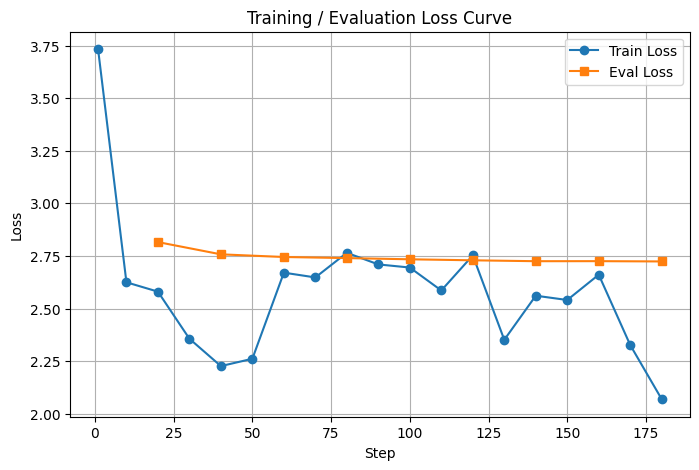

In [57]:
main()

# Loss Monitoring and Function

Based on the graph, the training Loss reflects how well the model fits the training data, and validation Loss evaluates how well the model generalizes to unseen data. From the logs, we can observe An overall decreasing trend in validation loss, indicating that the model is learning meaningful patterns. Some fluctuations in training loss, which are expected due to the small dataset size and stochastic optimization.

We use cross-entropy loss as the training objective, which is standard for language modeling tasks. Technically, the cross-entropy mainly measures the difference between the predicted probability distribution of the model and the true token distribution. Intuitively, if the model assigns high probability to the correct token, the loss will be low; If the model is uncertain or wrong, the loss will be high. 

Cross-entropy is used because it directly measures how well the model predicts the correct next token in a sequence. In language modeling, each token can be viewed as a class, making the task a multi-class classification problem, where cross-entropy is particularly well-suited. More importantly, minimizing cross-entropy is equivalent to maximizing the likelihood of the correct sequence, aligning naturally with the objective of training language models.

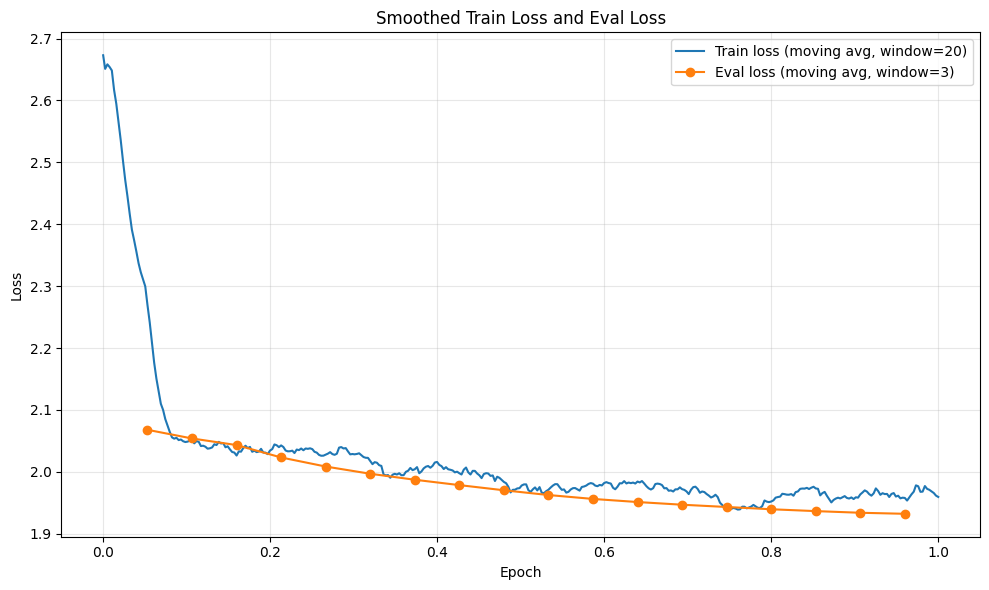

In [60]:
display(Image(filename="C:/Projects/ESE5971/outputs/output.png"))

The figure shows the smoothed training loss and evaluation loss during fine-tuning using the Qwen 7B model on a dataset of 60K samples. Overall, both training and evaluation losses exhibit a clear downward trend, indicating that the model is effectively learning from the data. The training loss decreases rapidly at the beginning and then gradually stabilizes, while the evaluation loss shows a more consistent decline throughout the process. Towards later, both curves converge to a similar range, suggesting that the model achieves good generalization without significant overfitting.

At the beginning of training, there is a large gap where the training loss is significantly higher than the eval loss. This phenomenon can be explained by several factors. First, during the initial phase, the model is still adapting to the new task distribution. Since LoRA fine-tuning starts from a pre-trained model, the model already has some general language understanding, which may allow it to perform relatively well on the validation set early on. However, the training process introduces randomness, causing the training loss to fluctuate and initially appear higher. Second, the training loss is computed on individual mini-batches, which introduces higher variance, especially at the start of training. In contrast, the evaluation loss is typically averaged over a more stable validation set, making it smoother and sometimes lower.

# Next Steps

Overall, the results from both experiments demonstrate that our training pipeline works well. This provides a foundation for scaling to larger datasets and exploring different hyperparameter configurations to further improve model performance. Therefore, our next steps will focus on works below:

- Tuning LoRA hyperparameters  
- Inference Script
- More evaluation metrics

# 3/4 Semester Check up Point

## Hyperparameter Ablation Study

Based on the timeline, we have completed the hyperparameter ablation study. Specifically, we compared different combinations of LoRA rank (8 and 16) and learning rates (1e-5 and 2e-5). The results indicate that a rank of 16 combined with a learning rate of 2e-5 achieves the best performance with evaluation loss is approximately 1.85. Given these results, we will use this best-performing model for subsequent inference.

In [15]:
import json
json_files = ['C:/Projects/ESE5971/reports/rank8_lr1e5.json', 
              'C:/Projects/ESE5971/reports/rank8_lr2e5.json', 
              'C:/Projects/ESE5971/reports/rank16_lr1e5.json', 
              'C:/Projects/ESE5971/reports/rank16_lr2e5.json']

for file_name in json_files:
    with open(file_name, 'r') as f:
        data = json.load(f)
    
    rank = data.get('rank')
    lr = data.get('learning_rate')
    final_train = data['train'][-1]['loss']
    final_eval = data['eval'][-1]['loss']
    
    print(f"Rank {rank}, LR {lr}")
    print(f"  - Final Train Loss: {final_train:.4f}")
    print(f"  - Final Eval Loss:  {final_eval:.4f}")
    print("-" * 30)

Rank 8, LR 1e-5
  - Final Train Loss: 1.9520
  - Final Eval Loss:  1.9212
------------------------------
Rank 8, LR 2e-5
  - Final Train Loss: 1.9019
  - Final Eval Loss:  1.9043
------------------------------
Rank 16, LR 1e-5
  - Final Train Loss: 1.8848
  - Final Eval Loss:  1.8997
------------------------------
Rank 16, LR 2e-5
  - Final Train Loss: 1.8413
  - Final Eval Loss:  1.8586
------------------------------


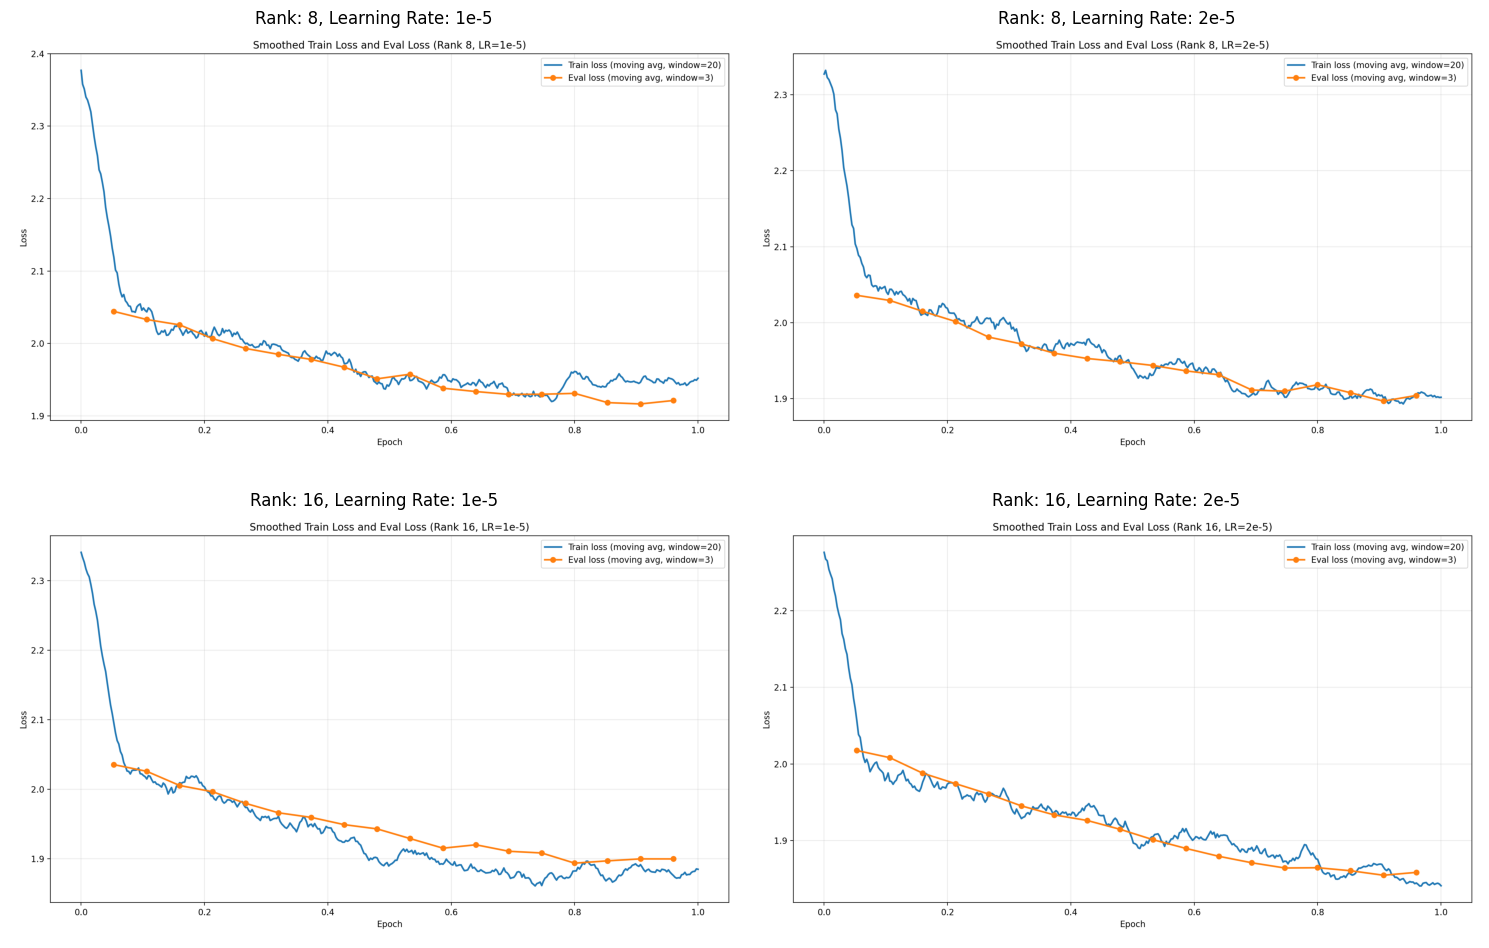

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

images = [
    'C:/Projects/ESE5971/reports/rank8_lr1e5.png', 
    'C:/Projects/ESE5971/reports/rank8_lr2e5.png',
    'C:/Projects/ESE5971/reports/rank16_lr1e5.png', 
    'C:/Projects/ESE5971/reports/rank16_lr2e5.png'
]

titles = [
    'Rank: 8, Learning Rate: 1e-5',
    'Rank: 8, Learning Rate: 2e-5',
    'Rank: 16, Learning Rate: 1e-5',
    'Rank: 16, Learning Rate: 2e-5'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')  
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

The 4 configurations demonstrates that the selection of hyperparameters dictates both the efficiency and the depth of domain-specific knowledge acquisition. Regarding the learning rate, the $2 \times 10^{-5}$ configuration exhibited loss descent gradient slightly steeper than that of the $1 \times 10^{-5}$ baseline. Furthermore, in the LoRA rank, Rank 16 displayed a capacity advantage. Compared to Rank 8, the higher rank provided a more expansive space for modeling complex semantics and ultimately achieving a lower evaluation loss. These results suggest that adapter rank in conjunction with a moderate learning rate is a critical pathway for enhancing model fitting performance.

# MedQA Score

In [21]:
import json
import pandas as pd

file_path = 'C:/Projects/ESE5971/reports/medqa_final_results.json'
with open(file_path, 'r') as f:
    data = json.load(f)

results = data['results']['medqa_4options']
summary_data = {
    "Metric": ["Accuracy", "Standard Error", "Sample Size"],
    "Value": [
        f"{results['acc,none']:.4f}", 
        f"{results['acc_stderr,none']:.4f}",
        results['sample_len']
    ]
}

df_summary = pd.DataFrame(summary_data)
print("MedQA-USMLE Evaluation Summary")
display(df_summary)

MedQA-USMLE Evaluation Summary


,Metric,Value
0,Accuracy,0.6426
1,Standard Error,0.0134
2,Sample Size,1273


# Inference

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

base_model_path = "C:/Projects/ESE5971/models/qwen2.5-7b"
lora_path = "C:/Projects/ESE5971/outputs/final_lora"

# 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

# Loading tokenizer and base model
tokenizer = AutoTokenizer.from_pretrained(base_model_path, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(
    base_model_path,
    quantization_config=bnb_config, 
    device_map="auto"              
)

# Loading LoRA adapter
model = PeftModel.from_pretrained(model, lora_path)
model.eval()

question = "A 58-year-old obese female comes to the clinic complaining of 'terrible pain' in her right knee. " \
"She says, It's been getting worse over the last few years. It's stiffest in the morning for about 10 minutes, " \
"but it really hurts after I've been walking around the grocery store or standing for a long time. She denies any recent injury or fever. "\
"On examination, you notice bony enlargements of the distal interphalangeal joints of her fingers and a grating sensation (crepitus) when moving her right knee. "\
"Which of the following is the most likely diagnosis?"

messages = [
    {"role": "system", "content": "You are a professional medical assistant."},
    {"role": "user", "content": question}
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

print("\n Generating Response...")
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.7,    
        top_p=0.9,  
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|im_end|>")
    )

generated_ids = outputs[0][inputs.input_ids.shape[1]:]
response = tokenizer.decode(generated_ids, skip_special_tokens=True)

print(f"\n Question: {question}")
print(f"\n Anwser: {response}")

c:\Projects\ESE5971\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 339/339 [00:08<00:00, 39.99it/s]



 Generating Response...

 Question: A 58-year-old obese female comes to the clinic complaining of 'terrible pain' in her right knee. She says, It's been getting worse over the last few years. It's stiffest in the morning for about 10 minutes, but it really hurts after I've been walking around the grocery store or standing for a long time. She denies any recent injury or fever. On examination, you notice bony enlargements of the distal interphalangeal joints of her fingers and a grating sensation (crepitus) when moving her right knee. Which of the following is the most likely diagnosis?

 Anwser: Based on the patient's symptoms and physical examination findings, the most likely diagnosis is **osteoarthritis**. Here’s why:

1. **History**: The patient describes chronic worsening pain in her right knee that has been ongoing for several years. This aligns with the progressive nature of osteoarthritis.
2. **Morning Stiffness**: Morning stiffness lasting for about 10 minutes is a common sym

Based on our evaluation on the MedQA benchmark, our fine-tuned model achieved an overall accuracy of 64%.

To further examine the model’s reasoning ability, we analyzed an example in detail. In this case, the model correctly inferred that the patient’s condition corresponds to Osteoarthritis, based on key clinical features such as short-duration morning stiffness, activity-related pain, and the presence of distal interphalangeal joint involvement.

Importantly, this diagnosis is consistent with the ground truth: Osteoarthritis is indeed one of the original answer choices in the MedQA dataset and is labeled as the correct answer. This example demonstrates that the model is not only capable of selecting the correct option, but also able to generate coherent reasoning that aligns with established medical knowledge.

# Next Step Until ESE Day

- **Conversational Memory** \
      Incorporate a memory mechanism (e.g., Sliding window) to enable multi-turn interactions, allowing the model to retain context and provide more consistent responses.
- **Frontend Development** \
      Build a lightweight frontend interface to support chat-based interaction, making the system more user-friendly and easier to demonstrate.

# Github Link

https://github.com/Draic111/ESE5971-LLM-Medical-Fine-Tuning